# **Introduction**

This notebook explores unsupervised learning through clustering and recommendation systems. It includes similarity-based exploration, KMeans and DBSCAN clustering, content-based recommendations, and collaborative filtering. All studies are performed on a real-world movie dataset and evaluated both qualitatively and quantitatively.

# Assignment 4 - Unsupervised Learning: Clustering and Recommendation

**Group number**: A-5 <br>
**Name student**: Zanou Rih & Sanaa El Marbouh<br>
**Student Number**: 300178068 & 300267783 <br>


##1. Dataset Description - Movies Dataset
&#128279; **Link**: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset  <br>

&#128100; **Author**: Rounak Banik <br>

**Size**: 6 CSV files ranging from 180 KB to 692,000 KB <br>
In this assignment, we will focus on:

- movies_dataset.csv: 24 columns, 45467 rows <br>
- ratings_small.csv: 4 columns, 100,005 rows  <br>

**Description**:  <br>

**Key Features**: <br>
We'll only focus on the features on the metadata.csv and small_ratings.csv


In [ ]:
# IMPORT STATEMENTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import cityblock, euclidean
import warnings
import difflib
import ast

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler



In [ ]:
! pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.3 MB/s eta 0:00:00


In [ ]:
# raw file URLs from github
url_metadata = "https://github.com/zanoudev/data-science-projects/raw/refs/heads/main/a4/movies_metadata.csv"
url_sm_ratings = "https://github.com/zanoudev/data-science-projects/raw/refs/heads/main/a4/ratings_small.csv"

#load DS
ds_metadata = pd.read_csv(url_metadata, low_memory=False)
ds_sm_ratings = pd.read_csv(url_sm_ratings)

In [ ]:
# display the first few rows of movies_metadata.csv
ds_metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
# display the first few rows of small_ratings_csv
ds_sm_ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


##2. Data Preparation

In [ ]:
# DATA CLEANING AND VERIFICATION

print(ds_metadata.shape)
print(ds_metadata.columns)

# Define a function to count custom missing values
def count_custom_missing(df):
    missing_counts = {}
    for col in df.columns:
        missing = df[col].apply(
            lambda x: pd.isna(x) or str(x).strip() in ["", "[]", "0"]
        )
        missing_counts[col] = missing.sum()
    return pd.Series(missing_counts)


# Check missing values
missing_metadata = count_custom_missing(ds_metadata)
missing_ratings = count_custom_missing(ds_sm_ratings)

print("Missing values in movies_metadata.csv:")
print(missing_metadata.sort_values(ascending=False))

print("\nMissing values in ratings_small.csv:")
print(missing_ratings.sort_values(ascending=False))

(45466, 24)
Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')
Missing values in movies_metadata.csv:
belongs_to_collection    40972
homepage                 37684
budget                   36573
tagline                  25055
production_companies     11878
production_countries      6285
spoken_languages          3835
genres                    2442
overview                   959
poster_path                386
runtime                    263
release_date                87
status                      87
imdb_id                     20
original_language           11
title                        6
vote_average                 6
vote_count         

Duplicates in metadata: 17
Duplicates in ratings: 0


,userId,movieId,rating,timestamp
count,100004.000000,100004.000000,100004.000000,1.000040e+05
mean,347.011310,12548.664363,3.543608,1.129639e+09
std,195.163838,26369.198969,1.058064,1.916858e+08
min,1.000000,1.000000,0.500000,7.896520e+08
25%,182.000000,1028.000000,3.000000,9.658478e+08
50%,367.000000,2406.500000,4.000000,1.110422e+09
75%,520.000000,5418.000000,4.000000,1.296192e+09
max,671.000000,163949.000000,5.000000,1.476641e+09


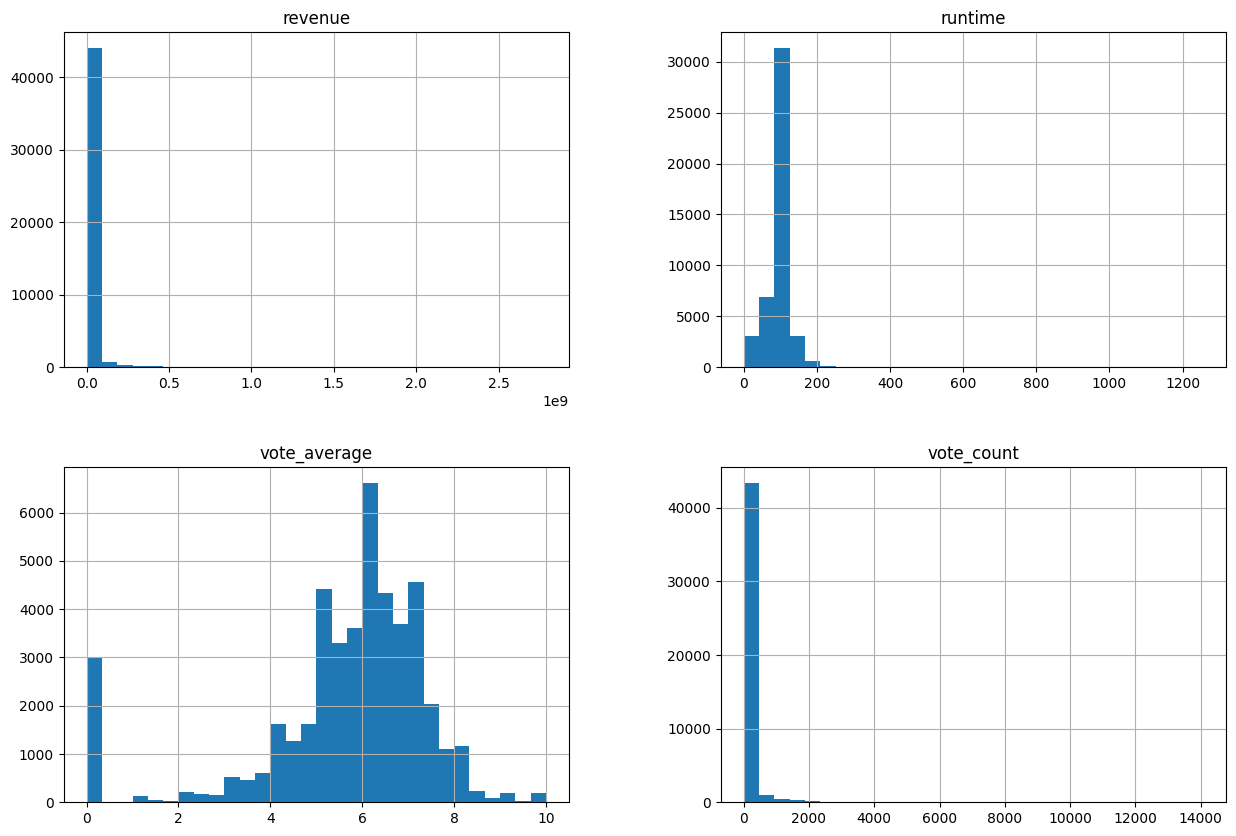

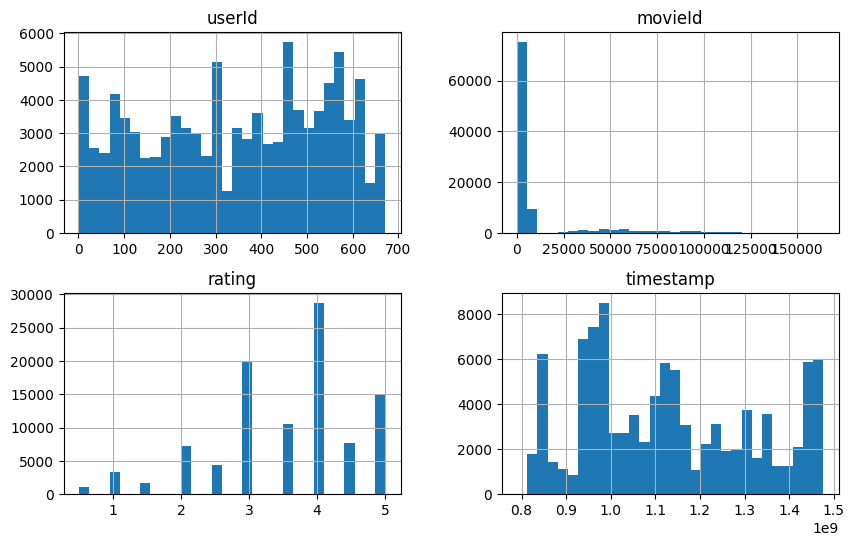

In [ ]:
# EDA

# visualize histograms for each numeric attribute in metadata
ds_metadata.select_dtypes(include=['number']).hist(bins=30, figsize=(15, 10))

# visualize histograms for each numeric attribute in small ratings
ds_sm_ratings.select_dtypes(include=['number']).hist(bins=30, figsize=(10, 6))


# drop unhashable columns before checking for duplicates
metadata_hashable = ds_metadata[[col for col in ds_metadata.columns if ds_metadata[col].apply(lambda x: isinstance(x, (int, float, str, bool, type(None)))).all()]]

# check for duplicated rows
print("Duplicates in metadata:", metadata_hashable.duplicated().sum())
print("Duplicates in ratings:", ds_sm_ratings.duplicated().sum())


# 3. basic stats for numeric columns
ds_metadata.describe()
ds_sm_ratings.describe()

In [ ]:
# Outlier Detection

print("\n=== Outlier Detection: vote_average ===")

# Quartile values
q1 = ds_metadata['vote_average'].quantile(0.25)
q3 = ds_metadata['vote_average'].quantile(0.75)
iqr = q3 - q1
print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")

# Outlier bounds
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")

# Detect and count outliers
outliers = ds_metadata[(ds_metadata['vote_average'] < lower) | (ds_metadata['vote_average'] > upper)]
print(f"Number of outliers detected: {len(outliers)}")

# Dataset size before filtering
print(f"Dataset shape before outlier removal: {ds_metadata.shape}")

# Drop outliers
ds_metadata = ds_metadata[(ds_metadata['vote_average'] >= lower) & (ds_metadata['vote_average'] <= upper)]

# Dataset size after filtering
print(f"Dataset shape after outlier removal: {ds_metadata.shape}")



=== Outlier Detection: vote_average ===
Q1 (25th percentile): 5.0
Q3 (75th percentile): 6.8
IQR (Q3 - Q1): 1.7999999999999998
Lower bound: 2.3000000000000003
Upper bound: 9.5
Number of outliers detected: 3603
Dataset shape before outlier removal: (45466, 24)
Dataset shape after outlier removal: (41857, 24)


In [ ]:
# Feature Engineering
import ast

# convert release_date to datetime and extract year
ds_metadata['release_date'] = pd.to_datetime(ds_metadata['release_date'], errors='coerce')
ds_metadata['release_year'] = ds_metadata['release_date'].dt.year

# parse genres
def safe_parse_genres(x):
    try:
        return ast.literal_eval(x) if pd.notnull(x) else []
    except (ValueError, SyntaxError):
        return []

ds_metadata['genres_parsed'] = ds_metadata['genres'].apply(safe_parse_genres)
ds_metadata['num_genres'] = ds_metadata['genres_parsed'].apply(len)

# compute average rating per movie
avg_ratings = ds_sm_ratings.groupby('movieId')['rating'].mean().reset_index()
avg_ratings.columns = ['movieId', 'avg_rating']


##3. Studies
###3.1 Study 1 - Similarity Measure

In [ ]:
print("Columns in ds_metadata:")
print(ds_metadata.columns.tolist())


# Select only necessary columns
ds_metadata = ds_metadata[["title", "genres", "revenue", "runtime", "budget"]]

# Remove custom missing values
for col in ds_metadata.columns:
    ds_metadata = ds_metadata[
        ds_metadata[col].apply(lambda x: str(x).strip() not in ["", "[]", "0"] and pd.notna(x))
    ]

# Convert to numeric (safely)
ds_metadata["revenue"] = pd.to_numeric(ds_metadata["revenue"], errors='coerce')
ds_metadata["budget"] = pd.to_numeric(ds_metadata["budget"], errors='coerce')
ds_metadata["runtime"] = pd.to_numeric(ds_metadata["runtime"], errors='coerce')

# Drop rows where conversion failed
ds_metadata = ds_metadata.dropna(subset=["revenue", "budget", "runtime"])

Columns in ds_metadata:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count', 'release_year', 'genres_parsed', 'num_genres']


In [ ]:
# Genre Similarity Jaccard
def parse_genres(genre_str):
    try:
        return set([d['name'] for d in ast.literal_eval(genre_str)])
    except:
        return set()

ds_metadata["parsed_genres"] = ds_metadata["genres"].apply(parse_genres)

def jaccard_similarity(set1, set2):
    return len(set1 & set2) / len(set1 | set2) if set1 | set2 else 0

def find_similar_genre(title):
    ref_genre = ds_metadata.loc[ds_metadata["title"] == title, "parsed_genres"].values[0]
    ds_metadata["genre_sim"] = ds_metadata["parsed_genres"].apply(lambda g: jaccard_similarity(ref_genre, g))
    return ds_metadata.sort_values("genre_sim", ascending=False).head(10)[["title", "parsed_genres", "genre_sim"]]

find_similar_genre("Toy Story")

,title,parsed_genres,genre_sim
45139,The Emoji Movie,"{Family, Comedy, Animation}",1.0
14167,Cloudy with a Chance of Meatballs,"{Family, Animation, Comedy}",1.0
15348,Toy Story 3,"{Family, Animation, Comedy}",1.0
4756,"Monsters, Inc.","{Family, Animation, Comedy}",1.0
11863,Surf's Up,"{Family, Animation, Comedy}",1.0
2997,Toy Story 2,"{Family, Animation, Comedy}",1.0
11742,How the Grinch Stole Christmas!,"{Family, Animation, Comedy}",1.0
18218,Happy Feet Two,"{Family, Animation, Comedy}",1.0
3309,Creature Comforts,"{Family, Animation, Comedy}",1.0
11959,The Simpsons Movie,"{Family, Animation, Comedy}",1.0


In [ ]:
# Revenue Similarity Manhattan
def find_similar_revenue(title):
    ref = ds_metadata.loc[ds_metadata["title"] == title, "revenue"].values[0]
    ds_metadata["rev_sim"] = ds_metadata["revenue"].apply(lambda r: -abs(r - ref))
    return ds_metadata.sort_values("rev_sim", ascending=False).head(10)[["title", "revenue"]]

find_similar_revenue("Titanic")

,title,revenue
1639,Titanic,1.845034e+09
26555,Star Wars: The Force Awakens,2.068224e+09
17818,The Avengers,1.519558e+09
25084,Jurassic World,1.513529e+09
28830,Furious 7,1.506249e+09
26558,Avengers: Age of Ultron,1.405404e+09
17437,Harry Potter and the Deathly Hallows: Part 2,1.342000e+09
22110,Frozen,1.274219e+09
42222,Beauty and the Beast,1.262886e+09
43255,The Fate of the Furious,1.238765e+09


In [ ]:
# Runtime Similarity Euclidean
def find_similar_runtime(title):
    ref = ds_metadata.loc[ds_metadata["title"] == title, "runtime"].values[0]
    ds_metadata["rt_sim"] = ds_metadata["runtime"].apply(lambda r: -euclidean([r], [ref]))
    return ds_metadata.sort_values("rt_sim", ascending=False).head(10)[["title", "runtime"]]

find_similar_runtime("Apollo 13")

,title,runtime
36234,100% Love,140.0
1949,The Negotiator,140.0
43510,The Age of Shadows,140.0
21197,Call Girl,140.0
43229,The Spacewalker,140.0
11299,Flyboys,140.0
10209,The Big Sky,140.0
10122,Batman Begins,140.0
10069,Star Wars: Episode III - Revenge of the Sith,140.0
38526,Saamy,140.0


In [ ]:
# Title Similarity Levenshtein Distance
import Levenshtein

def find_similar_title(title):
    ds_metadata["title_sim"] = ds_metadata["title"].apply(lambda t: -Levenshtein.distance(title.lower(), t.lower()))
    return ds_metadata.sort_values("title_sim", ascending=False).head(10)[["title", "title_sim"]]

find_similar_title("Fight Club")

,title,title_sim
2843,Fight Club,0
38577,Flight Crew,-4
39335,Lights Out,-5
10808,Eight Below,-5
25705,Fishtales,-5
10384,Flightplan,-5
2290,First Blood,-6
4352,The Blob,-6
30703,Rough Cut,-6
7542,Nightbreed,-6


###3.2 Study 2 - Clustering Algorithms

In [ ]:
# Additional Cleaning

# Convert budget and revenue to numeric, clean up rows with missing or zero values
ds_metadata['budget'] = pd.to_numeric(ds_metadata['budget'], errors='coerce')
ds_metadata['revenue'] = pd.to_numeric(ds_metadata['revenue'], errors='coerce')
ds_metadata['runtime'] = pd.to_numeric(ds_metadata['runtime'], errors='coerce')

# Drop rows with missing or 0 values in relevant columns
df_clean = ds_metadata[['budget', 'revenue', 'runtime']].dropna()
df_clean = df_clean[(df_clean['budget'] > 0) & (df_clean['revenue'] > 0) & (df_clean['runtime'] > 0)]


In [ ]:
# Study 2
# --- Choose combinations of features for clustering
features_list = [
    ['budget', 'revenue'],
    ['runtime', 'budget']
]

# Standardize data
scalers = [StandardScaler().fit(df_clean[features]) for features in features_list]
scaled_features = [scaler.transform(df_clean[features]) for scaler, features in zip(scalers, features_list)]

# Function to plot clusters
def plot_clusters(X, labels, title):
    plt.figure(figsize=(8, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.show()

# Helper to plot 2x2 grid
def plot_2x_grid(X, titles, label_sets, feature_names, algo_name):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        sc = ax.scatter(X[:, 0], X[:, 1], c=label_sets[i], cmap='viridis', s=40, edgecolor='k')
        ax.set_title(titles[i])
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
        ax.grid(True)
    fig.suptitle(f'{algo_name} Clustering on {feature_names[0]} vs {feature_names[1]}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

--- KMeans Clustering Results ---


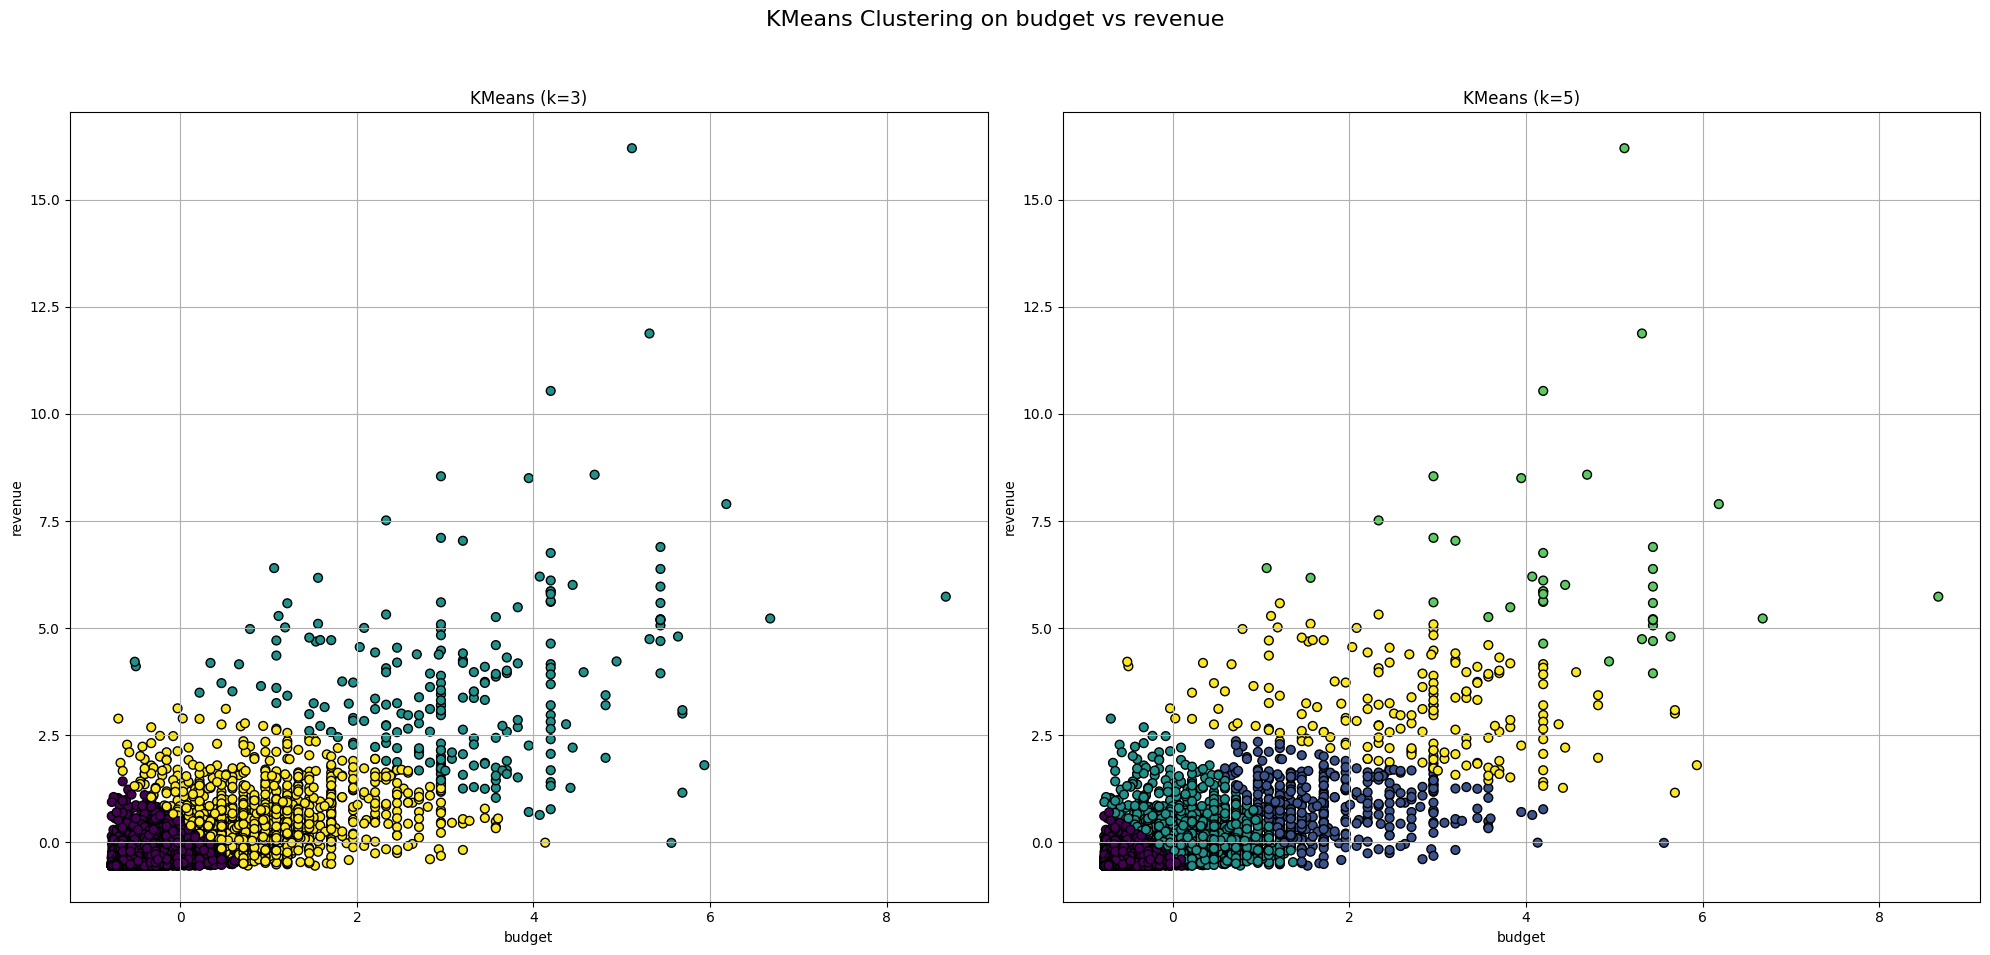

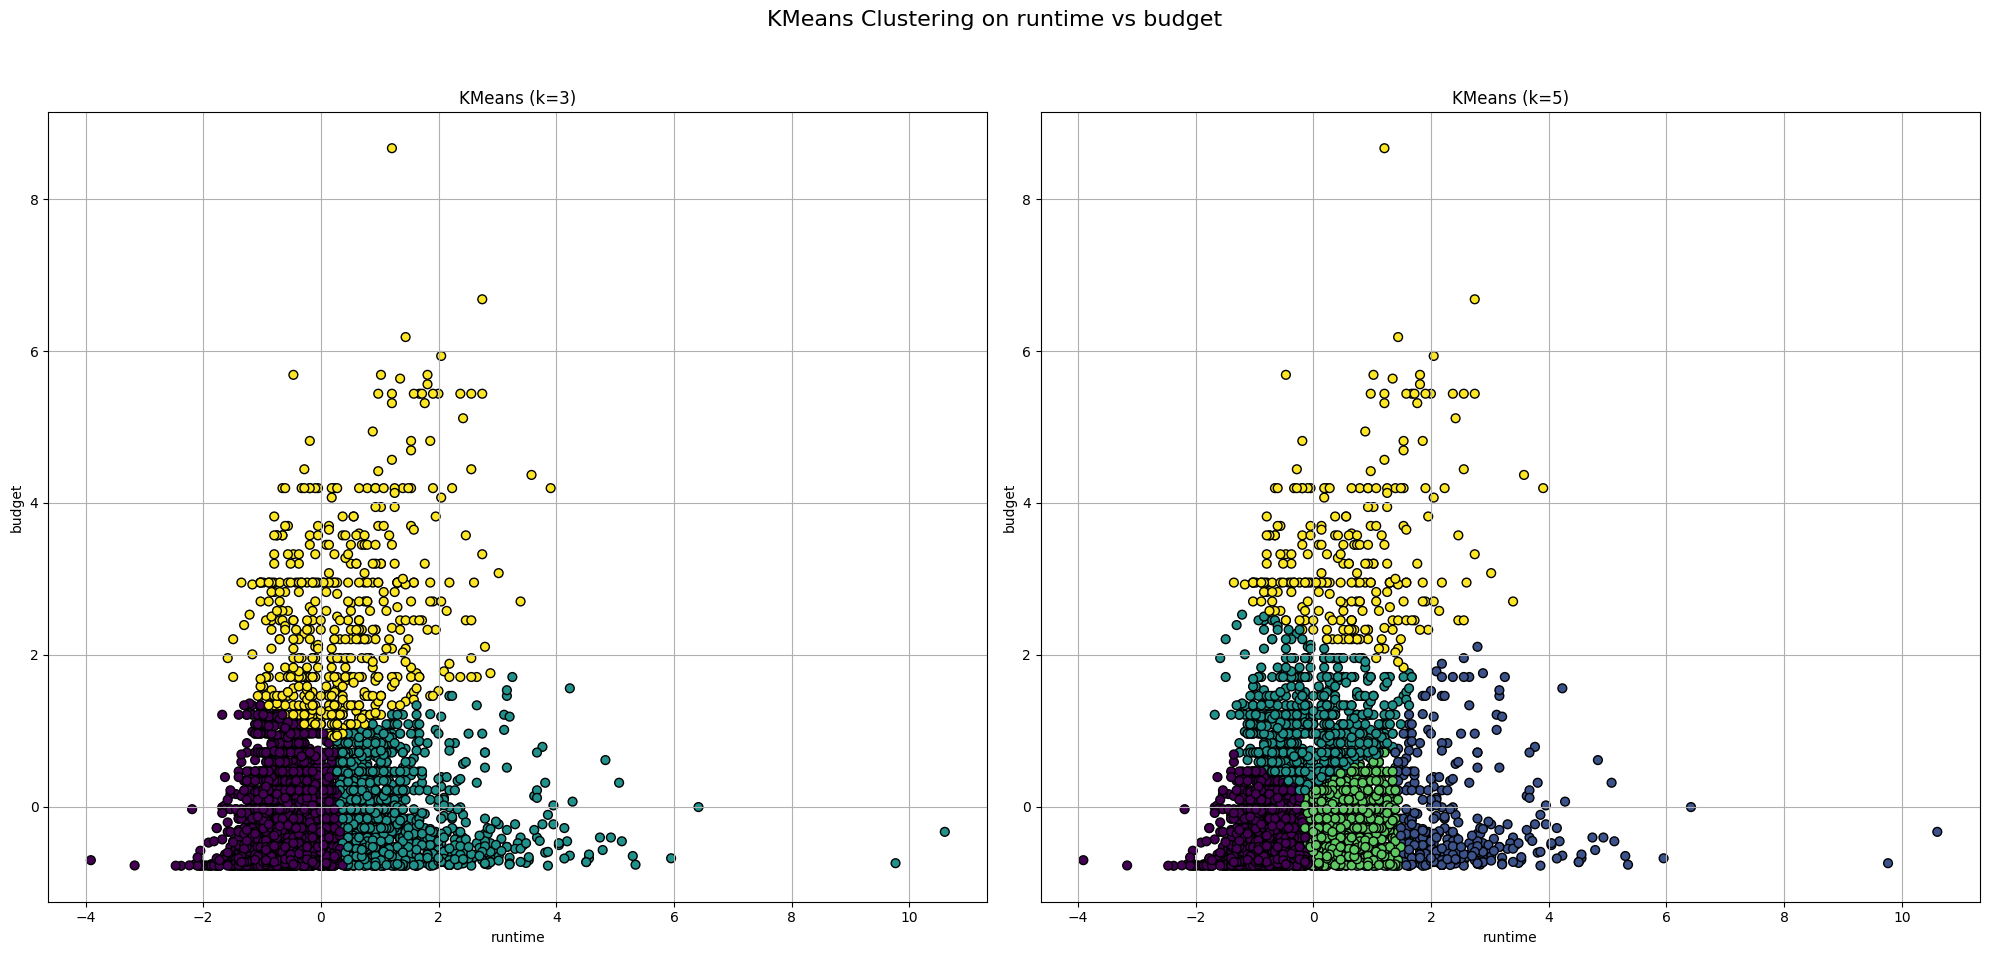

In [ ]:
print("--- KMeans Clustering Results ---")

for idx, X in enumerate(scaled_features):
    k_values = [3, 5]
    titles = []
    label_sets = []
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        titles.append(f"KMeans (k={k})")
        label_sets.append(labels)
    # duplicate plots to fill 2x2
    titles *= 2
    label_sets *= 2
    plot_2x_grid(X, titles, label_sets, features_list[idx], "KMeans")

--- DBSCAN Clustering Results ---


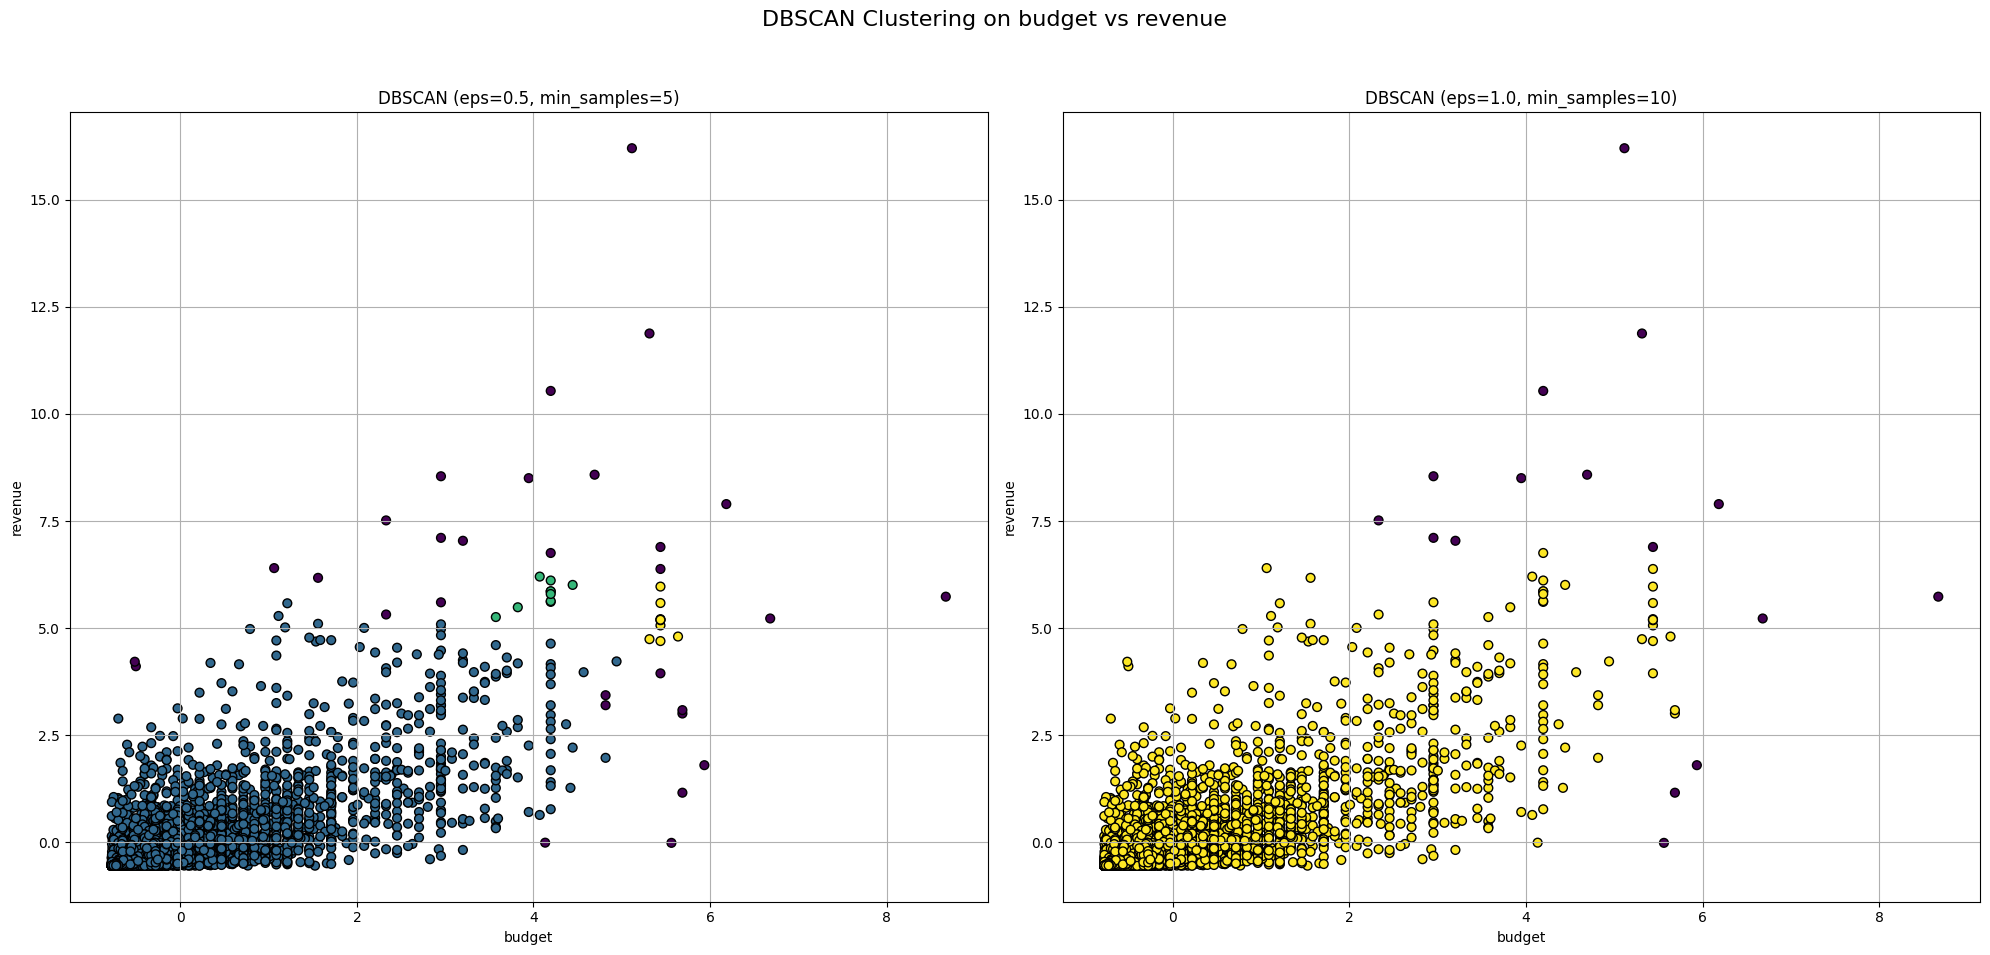

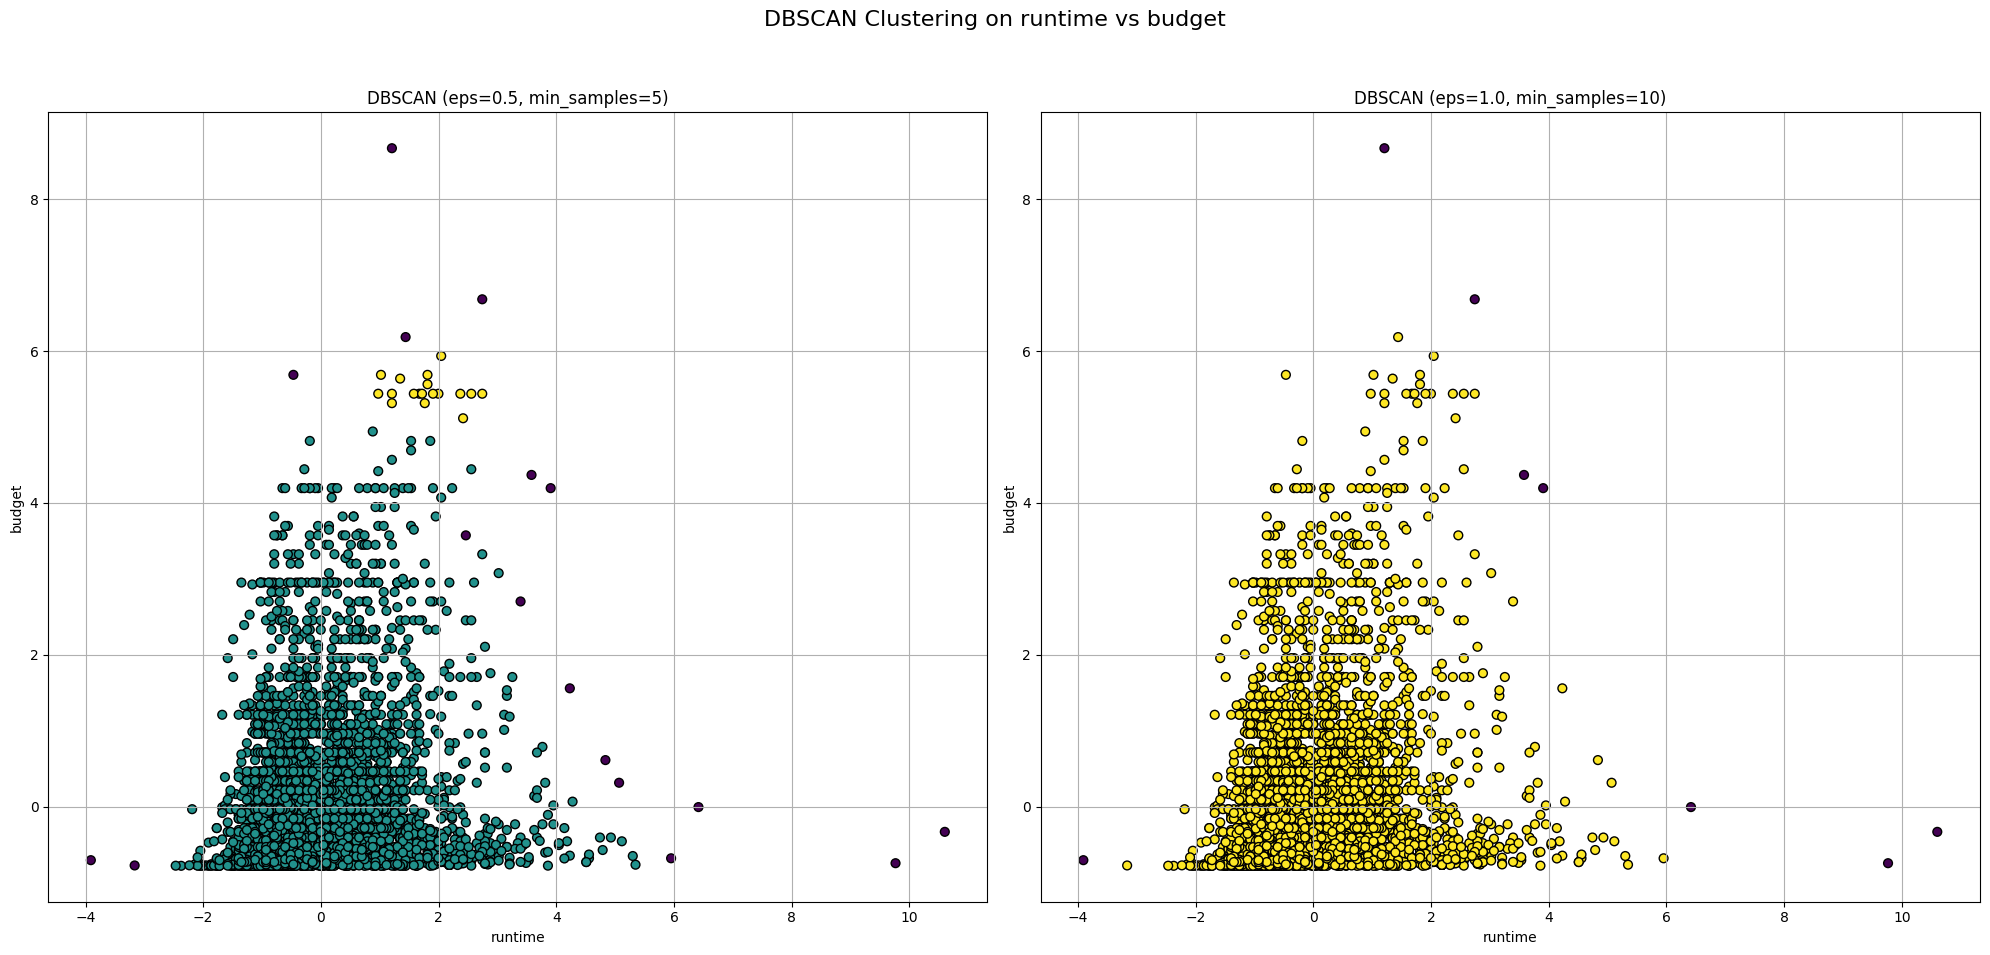

In [ ]:
print("--- DBSCAN Clustering Results ---")

for idx, X in enumerate(scaled_features):
    db_params = [(0.5, 5), (1.0, 10)]
    titles = []
    label_sets = []
    for eps_val, min_samples_val in db_params:
        dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
        labels = dbscan.fit_predict(X)
        titles.append(f"DBSCAN (eps={eps_val}, min_samples={min_samples_val})")
        label_sets.append(labels)
    # duplicate plots to fill 2x2
    titles *= 2
    label_sets *= 2
    plot_2x_grid(X, titles, label_sets, features_list[idx], "DBSCAN")

#### Discussion
**1. Feature Set: Budget vs Revenue**

KMeans:

- With k=3, we see broader clusters that capture general trends (e.g., low budget-low revenue vs high budget-high revenue).
- With k=5, finer distinctions emerge — such as mid-budget or outliers with high revenue and modest budgets.

- However, KMeans assumes spherical clusters and forces all the data points into groups even if they don't belong

DBSCAN:

* This algorithm is much more sensitive to the actual shape of the data

* With tighter/sctricter settings (lower eps and min_samples), DBSCAN considers a lot of points as noise, especially outliers (e.g., unusually profitable or loss-making films).

* Looser settings (eps=1.0) reduce the noise but can cause large clusters that don't hold significant meaning

* DBSCAN is good at detecting anomalies, which could be useful for spotting unusually successful or risky movie investments.

**2. Feature Set: Runtime vs Budget**

KMeans:

* shows a consistent partitioning of the dataset.

* Clusters follow vertical bands in the graph, separating by budget tiers, with some influence from runtime.

* However, runtime doesn’t create as much clear natural separation, anf the budget is dominating the structure.

DBSCAN:

* At tighter settings, some clusters appear, but most points are treated as one big blob or as noise.

* Looser parameters result in fewer noise points, but the clusters remain vague and imprecise.

**Conclusion:**

KMeans seems more appropriate for this dataset:

--> It provides clean, interpretable clusters, especially for budget vs revenue, where the separation aligns with intuitive business categories.

--> It’s predictable and consistent, and visually the clusters align with what we'd expect in film production tiers (e.g., independant films vs blockbusters).

--> DBSCAN shines for outlier detection, but struggles to form meaningful core clusters here unless the parameters are tuned very carefully.

--> It’s less suited to datasets where points are tightly packed and don’t form clear density-based groupings — which appears to be the case with runtime vs budget.

###3.3 Study 3 - Content-Based Recommendation System

In [ ]:
# Study 3
# --- Heuristic 1: Combines Genre, Runtime, and Revenue similarities ---
def content_based_recommendation_heuristic1(target_title,
                                            weights={'genre': 0.4, 'runtime': 0.3, 'revenue': 0.3}):
    # Get the target movie row from ds_metadata
    target_movie = ds_metadata[ds_metadata['title'] == target_title].iloc[0]

    # Extract target features
    target_genres = target_movie['parsed_genres']
    target_runtime = target_movie['runtime']
    target_revenue = target_movie['revenue']

    # Reuse Study 1 similarity functions:
    # Genre similarity using jaccard_similarity (already defined)
    ds_metadata['sim_genre'] = ds_metadata['parsed_genres'].apply(lambda g: jaccard_similarity(target_genres, g))

    # Runtime similarity (negative Euclidean distance)
    ds_metadata['sim_runtime'] = ds_metadata['runtime'].apply(lambda r: -euclidean([r], [target_runtime]))

    # Revenue similarity (negative absolute difference)
    ds_metadata['sim_revenue'] = ds_metadata['revenue'].apply(lambda r: -abs(r - target_revenue))

    # Combine the similarities with the chosen weights
    ds_metadata['combined_score'] = (weights['genre'] * ds_metadata['sim_genre'] +
                                     weights['runtime'] * ds_metadata['sim_runtime'] +
                                     weights['revenue'] * ds_metadata['sim_revenue'])

    # Exclude the target movie from recommendations and sort by combined score
    recommendations = ds_metadata[ds_metadata['title'] != target_title].sort_values('combined_score', ascending=False)

    return recommendations[['title', 'combined_score', 'sim_genre', 'sim_runtime', 'sim_revenue']].head(10)


- For Heuristic 1, I combined three features: genre, runtime, and revenue. The idea was to recommend movies that are similar in style (genre), similar in how long they are (runtime), and made or earned a similar amount of money (revenue). Genre is compared using Jaccard similarity, since movies often share multiple genres, and runtime and revenue are both numeric, so I used Euclidean distance and absolute difference to capture how close the numbers are. This combo makes sense because people who like a certain type of movie—say, family animation or action thrillers—often look for something with the same general vibe and pacing. Including revenue gives a clue about production value or popularity, which can affect someone’s interest too.

In [ ]:
# --- Heuristic 2: Combines Title, Genre, and Length similarities ---
def content_based_recommendation_heuristic2(target_title,
                                            weights={'title': 0.4, 'genre': 0.3, 'length': 0.3}):
    # Get the target movie row from ds_metadata
    target_movie = ds_metadata[ds_metadata['title'] == target_title].iloc[0]

    # Extract target features
    target_title_text = target_movie['title']
    target_genres = target_movie['parsed_genres']
    target_length = target_movie['runtime']  # "length" is treated as runtime

    # Title similarity using Levenshtein distance (negative distance gives higher scores for similar titles)
    ds_metadata['sim_title'] = ds_metadata['title'].apply(lambda t: -Levenshtein.distance(target_title_text.lower(), t.lower()))

    # Genre similarity using jaccard_similarity (already defined)
    ds_metadata['sim_genre'] = ds_metadata['parsed_genres'].apply(lambda g: jaccard_similarity(target_genres, g))

    # Length similarity (using runtime, negative Euclidean distance)
    ds_metadata['sim_length'] = ds_metadata['runtime'].apply(lambda r: -euclidean([r], [target_length]))

    # Combine the similarities with the chosen weights
    ds_metadata['combined_score'] = (weights['title'] * ds_metadata['sim_title'] +
                                     weights['genre'] * ds_metadata['sim_genre'] +
                                     weights['length'] * ds_metadata['sim_length'])

    # Exclude the target movie and sort by combined score
    recommendations = ds_metadata[ds_metadata['title'] != target_title].sort_values('combined_score', ascending=False)

    return recommendations[['title', 'combined_score', 'sim_title', 'sim_genre', 'sim_length']].head(10)


- For Heuristic 2, I went with title similarity, genre, and runtime. This one is a bit more stylistic. Title similarity (using Levenshtein distance) might sound random at first, but often, titles give subtle hints about the tone or themes of a movie. For example, dark or action-heavy movies tend to have shorter, punchy titles. I paired that with genre again (because it’s important) and runtime to keep things in a similar narrative scope. This heuristic is meant to capture more of a "feel" rather than just production stats.

In [ ]:
# --- Simulate 3 recommendation requests with both heuristics ---
print("\nRecommendations for 'Toy Story' using Heuristic 1:")
print(content_based_recommendation_heuristic1("Toy Story"))

print("\nRecommendations for 'Toy Story' using Heuristic 2:")
print(content_based_recommendation_heuristic2("Toy Story"))

print("\nRecommendations for 'Apollo 13' using Heuristic 1:")
print(content_based_recommendation_heuristic1("Apollo 13"))

print("\nRecommendations for 'Apollo 13' using Heuristic 2:")
print(content_based_recommendation_heuristic2("Apollo 13"))

print("\nRecommendations for 'Fight Club' using Heuristic 1:")
print(content_based_recommendation_heuristic1("Fight Club"))

print("\nRecommendations for 'Fight Club' using Heuristic 2:")
print(content_based_recommendation_heuristic2("Fight Club"))


Recommendations for 'Toy Story' using Heuristic 1:
                                    title  combined_score  sim_genre  \
25184              Penguins of Madagascar         -584.70       0.75   
13635            X-Men Origins: Wolverine      -147358.50       0.00   
3893                      What Women Want      -167315.90       0.25   
10122                       Batman Begins      -199409.70       0.00   
12216                  The Golden Compass      -395760.30       0.00   
18069            The Adventures of Tintin      -484196.32       0.20   
20536               G.I. Joe: Retaliation      -503335.20       0.00   
13693                Terminator Salvation      -660319.80       0.00   
19473                             Taken 2      -776184.90       0.00   
17444  Captain America: The First Avenger      -895290.60       0.00   

       sim_runtime  sim_revenue  
25184        -11.0      -1939.0  
13635        -26.0    -491169.0  
3893         -46.0    -557674.0  
10122        -59.0 

# **Comparison and Relevance**

- Looking at the recommendations, the two heuristics definitely gave me different results for the same movie. Heuristic 1 leaned more into production-based matches—like for Toy Story, it found Penguins of Madagascar, which is a solid match. But after that, some of the results felt off, probably because huge differences in revenue were dragging the scores down. So while genre and runtime were helping, revenue was overpowering the rest sometimes, which made a few recommendations not super relevant.

- Heuristic 2, on the other hand, gave results that felt a bit closer in vibe—like for Apollo 13, it found movies with similar runtime and genres, and sometimes even title patterns. The scores were also more stable (smaller range), which helped the ranking make more sense. It wasn’t perfect—title similarity isn’t always meaningful—but overall, this one felt more balanced. If I had to pick, Heuristic 2 gave results that felt more relevant to the kind of movie I was searching for, at least from a qualitative, user-focused point of view.










###3.4 Study 4 - Collaborative Filtering Recommendation System

In [ ]:
# Study 4

from scipy.sparse.linalg import svds

# Create the utility matrix (users x movies), filling missing ratings with 0
utility_matrix = ds_sm_ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Save a copy of the utility matrix for training
train_matrix = utility_matrix.copy().values

# Identify nonzero ratings positions to sample for the Gold Standard (GS)
nonzero_indices = np.array(np.where(train_matrix != 0)).T
np.random.shuffle(nonzero_indices)
holdout_size = int(0.1 * len(nonzero_indices))
holdout_indices = nonzero_indices[:holdout_size]

# Remove 10% of ratings and store them as the Gold Standard
gold_standard = []  # list of tuples (user_index, movie_index, actual_rating)
for idx in holdout_indices:
    user_idx, movie_idx = idx
    gold_standard.append((user_idx, movie_idx, train_matrix[user_idx, movie_idx]))
    train_matrix[user_idx, movie_idx] = 0  # Remove the rating for training



- I started by building the utility matrix from the ratings_small.csv file—essentially, a table where each row is a user and each column is a movie, with the ratings filled in (and missing values set to zero).
- I filled in missing values with zero and then randomly held out 10% of the non-zero ratings as my Gold Standard for evaluation. This way, I could later compare the predictions from my matrix factorization model against actual ratings.

In [ ]:
# Matrix Factorization using SVD
# Test different latent dimensions
latent_dims = [10, 20, 50]
evaluation_results = []

for k_val in latent_dims:
    # Perform SVD with current latent dimension
    U, sigma, Vt = svds(train_matrix, k=k_val)
    sigma = np.diag(sigma)
    R_pred_k = np.dot(np.dot(U, sigma), Vt)

- To test how the number of latent features affects performance, I ran matrix factorization using SVD with k = 10, 20, and 50. For each value, I decomposed the ratings matrix and reconstructed the predicted ratings. This helped me compare how different model complexities influence recommendation quality.

In [ ]:
# Function to get top-N recommendations for a given user index
def get_recommendations(user_index, R_pred, train_matrix, utility_matrix, top_n=10):
    # Find movies already rated by the user (we exclude them)
    rated_indices = np.where(train_matrix[user_index, :] > 0)[0]
    user_pred = R_pred[user_index, :].copy()
    user_pred[rated_indices] = -np.inf  # Mask out already rated movies
    top_indices = np.argsort(user_pred)[-top_n:][::-1]
    # Map indices to movie IDs (i.e., columns in utility_matrix)
    recommended_movie_ids = utility_matrix.columns[top_indices]
    return recommended_movie_ids, user_pred[top_indices]

- Then, I wrote a function to recommend the top-N movies for any user by filtering out the ones they’ve already rated. It ranks the remaining movies by predicted score and returns the best ones.

In [ ]:
# Simulate recommendations for 3 users (using user IDs 1, 2, and 3)
for user in [1, 2, 3]:
    # Get the row index corresponding to the user (assuming userId is the index)
    user_index = utility_matrix.index.get_loc(user)
    movie_ids, scores = get_recommendations(user_index, R_pred, train_matrix, utility_matrix, top_n=10)
    print(f"\nRecommendations for User {user}:")
    for mid, score in zip(movie_ids, scores):
        print(f"MovieID: {mid}, Predicted Rating: {score:.2f}")


Recommendations for User 1:
MovieID: 1214, Predicted Rating: 0.19
MovieID: 1374, Predicted Rating: 0.15
MovieID: 750, Predicted Rating: 0.14
MovieID: 541, Predicted Rating: 0.14
MovieID: 1200, Predicted Rating: 0.14
MovieID: 969, Predicted Rating: 0.13
MovieID: 924, Predicted Rating: 0.12
MovieID: 1204, Predicted Rating: 0.12
MovieID: 2916, Predicted Rating: 0.12
MovieID: 1282, Predicted Rating: 0.12

Recommendations for User 2:
MovieID: 318, Predicted Rating: 3.37
MovieID: 380, Predicted Rating: 3.32
MovieID: 593, Predicted Rating: 3.30
MovieID: 592, Predicted Rating: 2.99
MovieID: 595, Predicted Rating: 2.65
MovieID: 344, Predicted Rating: 2.51
MovieID: 316, Predicted Rating: 2.23
MovieID: 231, Predicted Rating: 2.20
MovieID: 597, Predicted Rating: 2.17
MovieID: 527, Predicted Rating: 2.16

Recommendations for User 3:
MovieID: 2571, Predicted Rating: 1.51
MovieID: 50, Predicted Rating: 1.42
MovieID: 2959, Predicted Rating: 1.35
MovieID: 2028, Predicted Rating: 1.25
MovieID: 858, Pre

Once I had the predicted ratings matrix, I simulated recommendations for three different users to see how the model would perform.

For each user, I filtered out the movies they had already rated and then ranked the remaining movies based on the predicted ratings. This provided a list of top recommendations.

- For User 1, the recommendations were all very low (with predicted ratings around 0.12 to 0.19), suggesting that this user might not have rated many movies highly or perhaps that the model doesn’t have enough data for them.
- For User 2, however, the predictions are much higher—movies with predicted ratings between roughly 1.93 and 3.37, which feels like a more confident recommendation list.
- User 3 has predicted ratings fall somewhere in between, around 0.94 to 1.51. These differences really highlight that the model behaves differently depending on the user’s rating history and the data available for them.

In [ ]:
# Evaluation 1: Calculate MSE on the Gold Standard

from sklearn.metrics import mean_squared_error

predictions = []
actuals = []
for (user_idx, movie_idx, actual_rating) in gold_standard:
    pred_rating = R_pred[user_idx, movie_idx]
    predictions.append(pred_rating)
    actuals.append(actual_rating)
mse = mean_squared_error(actuals, predictions)
print("\nMSE on Gold Standard: ", mse)



MSE on Gold Standard:  8.69662133826231


- When I evaluated the model using Mean Squared Error (MSE) on the held-out Gold Standard data, I got an MSE of about 8.70. This number might seem high, especially considering movie ratings typically range from 0 to 5. It indicates that, on average, the predictions deviate quite a bit from the actual ratings.
- This result makes me think there’s still some room for improvement in the model—perhaps more tuning of the latent dimensions or additional regularization could help lower this error.

In [71]:
# First, define a helper function to transform a rating to binary relevance
def binary_transform(rating):
    return 1 if rating >= 4 else 0

# Now, define a function to evaluate a single user's recommendations for a given K (e.g., 5 or 10)
def evaluate_user(user_index, R_pred, train_matrix, utility_matrix, gs_data, K):
    # Exclude movies that the user already rated in the training set
    rated_indices = np.where(train_matrix[user_index, :] > 0)[0]
    user_pred = R_pred[user_index, :].copy()
    user_pred[rated_indices] = -np.inf  # Mask already rated movies

    # Get the top-K recommended movie indices based on predicted scores
    top_indices = np.argsort(user_pred)[-K:][::-1]

    # Extract the set of movies that are relevant in the Gold Standard for the given user
    relevant_set = {m_idx for (u_idx, m_idx, rating) in gs_data
                    if u_idx == user_index and binary_transform(rating) == 1}

    # Calculate Precision@K: number of relevant movies in top K divided by K
    hits = sum(1 for idx in top_indices if idx in relevant_set)
    precision = hits / K if K > 0 else 0

    # Calculate Reciprocal Rank (RR): reciprocal of the rank of the first relevant movie
    rr = 0
    for rank, idx in enumerate(top_indices, start=1):
        if idx in relevant_set:
            rr = 1 / rank
            break
    return precision, rr

# Evaluate over all users who have at least one rating in the Gold Standard (GS)
precision_at_5_list = []
precision_at_10_list = []
rr_list = []

# Get unique user indices present in the Gold Standard
unique_users = set(u for (u, m, r) in gold_standard)

for user_idx in unique_users:
    p5, rr = evaluate_user(user_idx, R_pred, train_matrix, utility_matrix, gold_standard, K=5)
    p10, _ = evaluate_user(user_idx, R_pred, train_matrix, utility_matrix, gold_standard, K=10)
    precision_at_5_list.append(p5)
    precision_at_10_list.append(p10)
    rr_list.append(rr)

avg_precision_at_5 = np.mean(precision_at_5_list) if precision_at_5_list else 0
avg_precision_at_10 = np.mean(precision_at_10_list) if precision_at_10_list else 0
avg_mrr = np.mean(rr_list) if rr_list else 0

print("Average Precision@5: ", avg_precision_at_5)
print("Average Precision@10: ", avg_precision_at_10)
print("Average MRR: ", avg_mrr)


Average Precision@5:  0.16636363636363638
Average Precision@10:  0.12484848484848486
Average MRR:  0.35111111111111115


For a ranking perspective, I transformed the held-out ratings into binary relevance (ratings 4 and 5 count as relevant) and then calculated Precision@5, Precision@10, and the Mean Reciprocal Rank (MRR).
- The average Precision@5 came out to roughly 16%, and Precision@10 was about 12%. This means that only about 1 in 5 of the top 5 recommendations were relevant according to the gold standard.
- The MRR of around 0.35 tells me that, on average, the first relevant movie appears around the third position in the recommendation list.
- While these metrics indicate that the system is making some reasonable predictions, they also point to opportunities for further refining the recommendation process.

# **Conclusion**

In terms of quantitative evaluation, the model achieved an MSE of 8.70, which is quite high considering the rating scale, suggesting that while it captures some overall patterns, it's not very precise in predicting exact ratings. The ranking metrics provided additional insight: Precision@5 was 16%, Precision@10 was 12%, and MRR was 0.35, meaning relevant movies were recommended, but often not at the very top.

These results indicate that the system has potential to identify general user preferences through collaborative filtering, but its accuracy and consistency are limited—likely due to sparse data or lack of sufficient user history. Overall, while the model shows it can capture latent user preferences, further tuning or more data would be needed to improve its performance.

## References
* CSI4142 Lecture Slides
* https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html
* https://stackoverflow.com/questions/53237195/trying-to-import-levenshtein-on-jupyter-ipython-windows
* https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
* https://medium.com/data-science/recommendation-system-matrix-factorization-d61978660b4b
* https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?select=ratings_small.csv
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.svds.html
*